# Advanced Analysis

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

### Data Loading

Load the dataset from an Excel file.

In [2]:
# Load the dataset; adjust the file path as needed.
file_path = "Data/data_cleaned.xlsx"  # Modify to point to your file location
try:
    df = pd.read_excel(file_path, header=0)
    print(f"Dataset loaded successfully with shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully with shape: (458, 21)


## A - Inter-relationships and Correlations Analysis

Here, we explores:
1. The correlation between **Total Entries per Station** and **Total Exits per Station**.
2. The relationship between **Annualised_En_Ex** and daily/weekly traffic figures.
3. The association between the data source (*Source*) and classification fields (*NLC*, *ASC*) with traffic volumes.
4. Outlier detection by identifying stations or modes with unusually high traffic standard deviations (*STDEV*).

The aim is to understand how traffic variables interact and to detect any anomalies that might warrant further investigation.


### 1. Correlation between Total Entries per Station and Total Exits per Station

This section evaluates whether there is a strong correlation between the total entries and exits reported for each station.


Pearson correlation between Total Entries and Total Exits: 0.996 (p-value: 0)


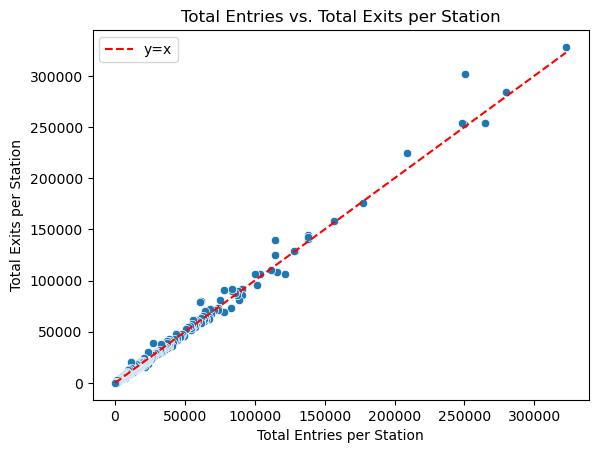

In [3]:
# Calculate Pearson correlation between 'Total Entries per Station' and 'Total Exits per Station'
entries = df['Total Entries per Station']
exits = df['Total Exits per Station']
corr_entries_exits, p_val = pearsonr(entries, exits)
print(f"Pearson correlation between Total Entries and Total Exits: {corr_entries_exits:.3f} (p-value: {p_val:.3g})")

# Visualise the relationship using a scatter plot
plt.figure()
sns.scatterplot(x=entries, y=exits)
plt.title("Total Entries vs. Total Exits per Station")
plt.xlabel("Total Entries per Station")
plt.ylabel("Total Exits per Station")
plt.plot([entries.min(), entries.max()], [entries.min(), entries.max()], 'r--', label='y=x')
plt.legend()
plt.show()

**Interpretation:**
- A high Pearson correlation coefficient (close to +1) would indicate that stations with high entries tend to also have high exits, suggesting a balanced flow.
- The scatter plot with the *y = x* reference line helps determine if the relationship is linear.


### 2. Correlation of Annualised_En_Ex with Daily and Weekly Traffic Figures

This section examines how the **Annualised_En_Ex** (annualised entries and exits) column correlates with:
- Average daily traffic (using columns such as `Average Entries per Day ` and `•\tAverage Exits per Day `)
- Total weekly traffic (`Total Weekly traffic`)

Adjust the column names if they include extraneous spaces or special characters.


Correlation between Annualised_En_Ex and Average Entries per Day: 0.995 (p-value: 0)
Correlation between Annualised_En_Ex and Average Exits per Day: 0.996 (p-value: 0)
Correlation between Annualised_En_Ex and Total Weekly Traffic: 0.996 (p-value: 0)


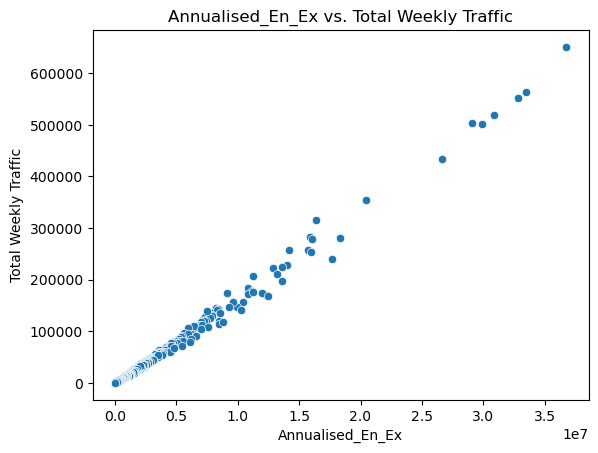

In [13]:
# Calculate correlations
annualised = df['Annualised_En_Ex']
avg_entries = df['Average Entries per Day ']
avg_exits   = df['•\tAverage Exits per Day ']
weekly_traffic = df['Total Weekly traffic']

corr_ann_avg_entries, p_val_entries = pearsonr(annualised, avg_entries)
corr_ann_avg_exits,   p_val_exits   = pearsonr(annualised, avg_exits)
corr_ann_weekly,      p_val_weekly  = pearsonr(annualised, weekly_traffic)

print(f"Correlation between Annualised_En_Ex and Average Entries per Day: {corr_ann_avg_entries:.3f} (p-value: {p_val_entries:.3g})")
print(f"Correlation between Annualised_En_Ex and Average Exits per Day: {corr_ann_avg_exits:.3f} (p-value: {p_val_exits:.3g})")
print(f"Correlation between Annualised_En_Ex and Total Weekly Traffic: {corr_ann_weekly:.3f} (p-value: {p_val_weekly:.3g})")

# Visualise one of these relationships
plt.figure()
sns.scatterplot(x=annualised, y=weekly_traffic)
plt.title("Annualised_En_Ex vs. Total Weekly Traffic")
plt.xlabel("Annualised_En_Ex")
plt.ylabel("Total Weekly Traffic")
plt.show()

**Interpretation:**
- A strong positive correlation (values near +1) between Annualised_En_Ex and daily/weekly traffic measures indicates that the annualised metric is a good proxy for daily activity.
- The scatter plot reveal that the relationship is linear.

### 3. Relationship between Data Source/Classifications and Traffic Volumes

Here, we investigate if the **Source** fields have any impact on traffic volumes.
We achieve this by grouping the data and comparing average traffic measures across the groups.


In [4]:
# Aggregating traffic measures based on 'Source'
source_group = df.groupby('Source').agg({
    'Total Entries per Station': 'mean',
    'Total Exits per Station': 'mean',
    'Total Weekly traffic': 'mean'
}).reset_index()
source_group.to_csv("source_group.csv", index=False)
print("Average Traffic Metrics by Data Source:")
print(source_group)

Average Traffic Metrics by Data Source:
          Source  Total Entries per Station  Total Exits per Station  \
0            APC               19608.194944             19335.103798   
1       Gateline               33244.869223             33315.670130   
2          Issue               13392.212754             13981.662107   
3      Loadweigh               31795.892077             33221.243702   
4   Manual Count               13328.007363             13519.989191   
5  Scale_earlier               14557.523703             16083.855773   
6         Scaled               14557.859895             14924.157871   

   Total Weekly traffic  
0          38943.298742  
1          66560.539353  
2          27373.874861  
3          65017.135779  
4          26847.996555  
5          30641.379476  
6          29482.017766  


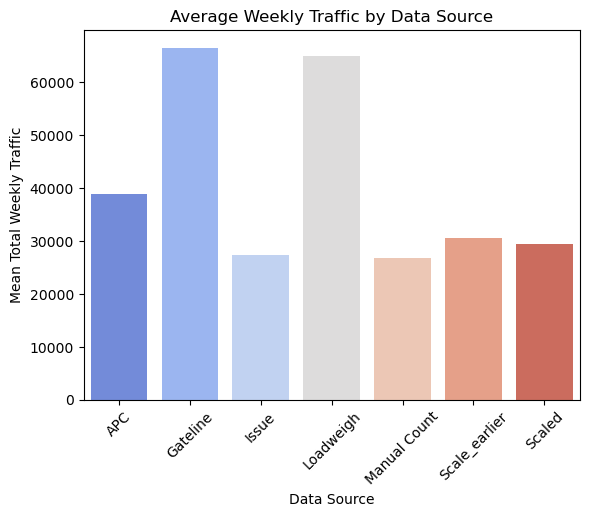

In [27]:
# Visualise the comparison for Data Source
plt.figure()
sns.barplot(x='Source', y='Total Weekly traffic', data=source_group, palette="coolwarm")
plt.title("Average Weekly Traffic by Data Source")
plt.xlabel("Data Source")
plt.ylabel("Mean Total Weekly Traffic")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**

We can see that we have better traffic in Gateline and Loadweigh. Differences in mean traffic volumes across data sources may indicate variations in collection methods or regional differences.

### 4. Outliers and Anomalies: Stations or Modes with High STDEV

This section identifies stations (or transport modes) with unusually high traffic variability as measured by the **STDEV** column.
We then try to determine if such anomalies might be due to data entry issues or genuine operational fluctuations.

In [39]:
# Identify statistical outliers in the 'STDEV' column using the IQR method
stdev = df['STDEV']
Q1 = stdev.quantile(0.25)
Q3 = stdev.quantile(0.75)
IQR = Q3 - Q1

# Define outliers as values beyond 1.5*IQR from the quartiles
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(stdev < lower_bound) | (stdev > upper_bound)]
outliers["ration"] = outliers['STDEV'] / outliers['Total Weekly traffic']
print(f"Number of outlier stations based on STDEV: {outliers.shape[0]}")
print("\nOutlier stations (first 10 rows):")
print(outliers[['Station', 'STDEV', 'Total Weekly traffic', 'ration']].head(10))

Number of outlier stations based on STDEV: 38

Outlier stations (first 10 rows):
                    Station         STDEV  Total Weekly traffic    ration
0  King's Cross St. Pancras   8541.463211         650890.640909  0.013123
1               Victoria LU  10232.456346         563955.938384  0.018144
2          London Bridge LU  11393.242153         517947.368182  0.021997
3             Oxford Circus  15808.626048         552506.616667  0.028613
4                 Stratford   9596.763929         502940.706699  0.019081
5               Waterloo LU  12526.298930         501810.027273  0.024962
6       Liverpool Street LU  11212.182068         433924.318182  0.025839
7            Paddington TfL   4965.195222         353319.231818  0.014053
8          Leicester Square  10062.258314         314935.725000  0.031950
9                 Euston LU   3834.187371         282887.957895  0.013554


C:\Users\Johann\AppData\Local\Temp\ipykernel_10452\4004190259.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["ration"] = outliers['STDEV'] / outliers['Total Weekly traffic']


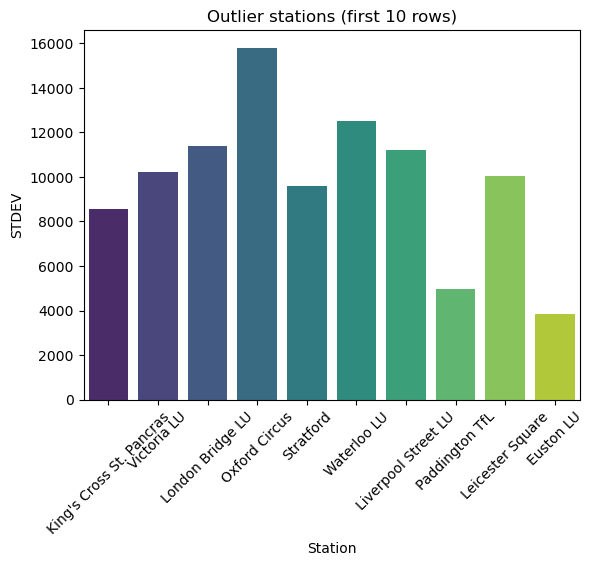

In [60]:
# Visualise the aggregated total weekly traffic by mode
plt.figure()
sns.barplot(x='Station', y='STDEV', data=outliers[:10], palette="viridis")
plt.title("Outlier stations (first 10 rows)")
plt.xlabel("Station")
plt.ylabel("STDEV")
plt.xticks(rotation=45)
plt.show()

**Interpretation: Outliers and Anomalies**

We can see that the standard deviation in each station have approximately the same ratio over the weekly traffic.

## B - Contextual and Operational Analysis

This section explores:
- **Operational Impact:**  
  How variations in transport mode usage and the distribution of entries/exits (across days or during special events) can help inform service planning and capacity allocation.

- **Data Source Reliability:**  
  Investigating differences in reporting or data quality across different sources and coverage areas, and assessing if the observed traffic values match expected patterns.

Each code section aggregates relevant data, creates visualisations, and prints statistical summaries to support actionable insights.


### 1. Operational Impact Analysis

### (a) Variations in Transport Mode Usage

We explore how different transport modes compare in terms of total passenger traffic.
This information is crucial for service planning (e.g. more capacity may be needed for the busier modes).

If one mode is handling significantly more passengers than others, resource allocation (e.g. additional trains, staffing, maintenance schedules) can be adjusted accordingly.

In [5]:
# Identify unique transport modes and aggregate traffic measures by mode
unique_modes = df['Mode'].unique()
print("Unique Transport Modes:", unique_modes)

# Aggregate total entries, exits, and total weekly traffic by transport mode
mode_group = df.groupby('Mode').agg({
    'Total Entries per Station': 'sum',
    'Total Exits per Station': 'sum',
    'Total Weekly traffic': 'sum'
}).reset_index()
mode_group.to_csv("mode_group.csv", index=False)
print("\nTraffic Metrics Aggregated by Transport Mode:")
print(mode_group)

Unique Transport Modes: ['LU' 'EZL' 'DLR' 'LO']

Traffic Metrics Aggregated by Transport Mode:
  Mode  Total Entries per Station  Total Exits per Station  \
0  DLR               9.088656e+05             9.104941e+05   
1  EZL               5.657745e+05             5.897684e+05   
2   LO               1.600033e+06             1.587173e+06   
3   LU               9.650766e+06             9.699918e+06   

   Total Weekly traffic  
0          1.819360e+06  
1          1.155543e+06  
2          3.187206e+06  
3          1.935068e+07  


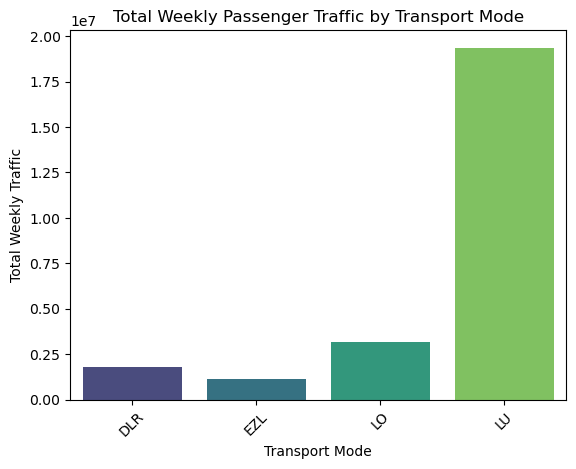

In [42]:
# Visualise the aggregated total weekly traffic by mode
plt.figure()
sns.barplot(x='Mode', y='Total Weekly traffic', data=mode_group, palette="viridis")
plt.title("Total Weekly Passenger Traffic by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Total Weekly Traffic")
plt.xticks(rotation=45)
plt.show()

### (b) Distribution of Entries and Exits Across Days

Here we compare the variability of passenger entries and exits between weekdays, Fridays, Saturdays, and Sundays.  
This analysis can reveal:
- Peak days (e.g. if weeddays consistently show higher traffic, or weekends reflect lower usage).
- Impact of events such as strikes or public holidays.

By understanding which days experience unusual surges or drops, scheduling, and resource allocation can be optimised.

In [43]:
# Descriptive statistics for daily entries and exits
daily_entries = df[['Entries_Weekday', 'Entries_Friday', 'Entries_Saturday', 'Entries_Sunday']].describe()
print("Daily Entries Statistics:")
print(daily_entries)

Daily Entries Statistics:
       Entries_Weekday  Entries_Friday  Entries_Saturday  Entries_Sunday
count       458.000000      458.000000        458.000000      458.000000
mean       7872.726184     7915.809724       7128.380803     4867.884049
std       10559.896239    10850.579673      11029.184489     7541.634811
min          20.000000       20.440183          0.000000        9.500000
25%        2433.612500     2419.900000       1942.362500     1322.736250
50%        4386.133897     4312.305900       3589.437500     2430.986111
75%        8515.868421     8635.535000       7213.531818     5009.325000
max       76546.650000    86808.000000      89500.909091    69804.000000


In [44]:
daily_exits   = df[['Exits_Weekday', 'Exits_Friday', 'Exits_Saturday', 'Exits_Sunday']].describe()
print("\nDaily Exits Statistics:")
print(daily_exits)


Daily Exits Statistics:
       Exits_Weekday  Exits_Friday  Exits_Saturday  Exits_Sunday
count     458.000000    458.000000      458.000000    458.000000
mean     7926.301644   7968.798960     7140.867847   4884.018128
std     10846.122547  11326.670824    11454.655554   7684.871283
min        14.000000     12.500000        0.000000      0.000000
25%      2432.512500   2342.648078     1882.830682   1351.309375
50%      4354.101331   4266.562500     3409.000000   2435.811364
75%      8717.398541   8573.041667     6991.090909   4989.700000
max     77884.450000  90424.454545    90458.777778  71424.636364


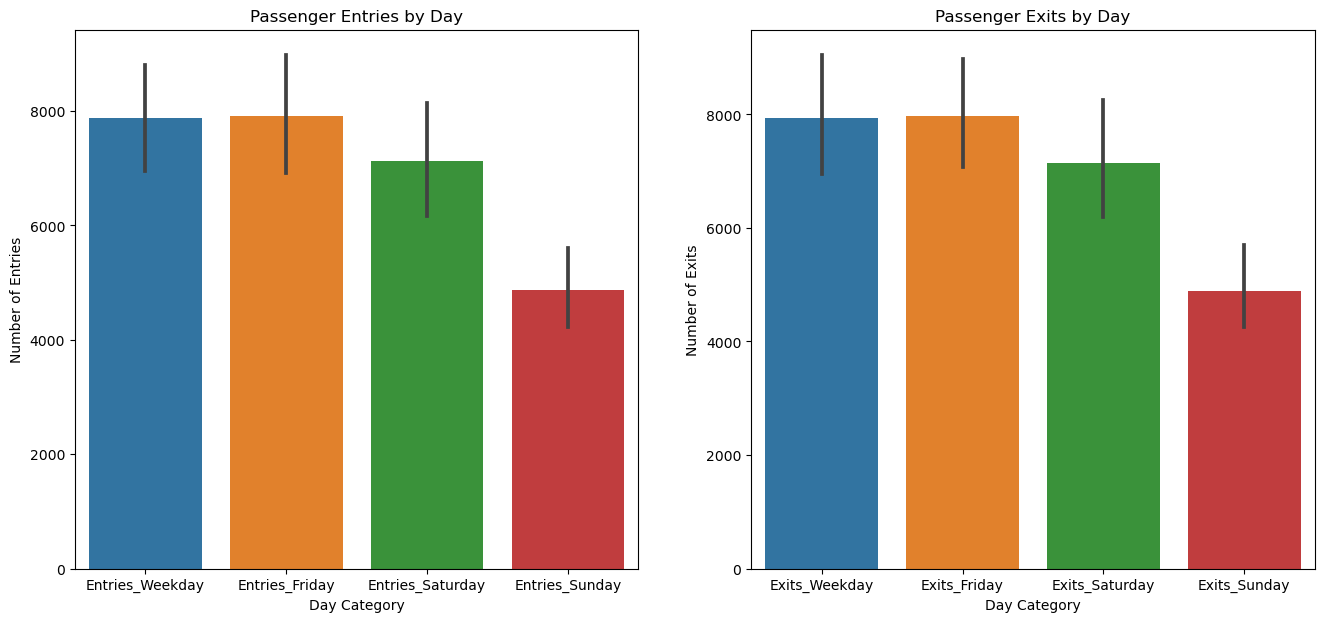

In [61]:
# Visualise the distribution of entries and exits using boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=df[['Entries_Weekday', 'Entries_Friday', 'Entries_Saturday', 'Entries_Sunday']], ax=axes[0])
axes[0].set_title("Passenger Entries by Day")
axes[0].set_xlabel("Day Category")
axes[0].set_ylabel("Number of Entries")

sns.barplot(data=df[['Exits_Weekday', 'Exits_Friday', 'Exits_Saturday', 'Exits_Sunday']], ax=axes[1])
axes[1].set_title("Passenger Exits by Day")
axes[1].set_xlabel("Day Category")
axes[1].set_ylabel("Number of Exits")

plt.show()

## 2. Station coverage Reliability

In this section, we examine:
- **Variations in Reporting and Data Quality:**  
  Grouping by station coverage (`Coverage`) can help identify any discrepancies or inconsistencies.

In [6]:
#  Group traffic metrics by station coverage
coverage_group = df.groupby('Coverage').agg({
    'Total Entries per Station': 'mean',
    'Total Exits per Station': 'mean',
    'Total Weekly traffic': 'mean'
}).reset_index()
coverage_group.to_csv("coverage_group.csv", index=False)
print("\nMean Traffic Metrics by Coverage:")
print(coverage_group)


Mean Traffic Metrics by Coverage:
                        Coverage  Total Entries per Station  \
0       DLR boarding / alighting               58401.356079   
1        LO boarding / alighting               20092.220688   
2        LU boarding / alighting               26187.085906   
3           Station entry / exit               28355.771365   
4  TfL Rail boarding / alighting               25174.102024   

   Total Exits per Station  Total Weekly traffic  
0             58033.432239         116434.788318  
1             20066.196052          40158.416740  
2             26387.060303          52574.146209  
3             28429.259095          56785.030461  
4             27530.114284          52704.216308  


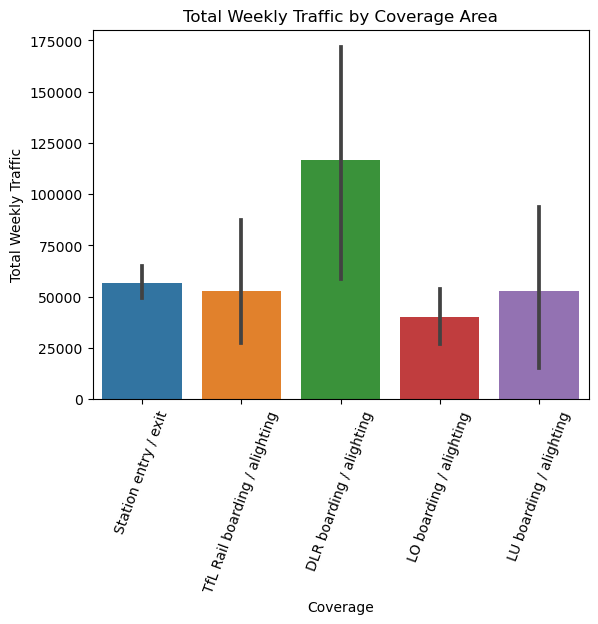

In [54]:
# Visualise traffic by coverage group
plt.figure()
sns.barplot(x='Coverage', y='Total Weekly traffic', data=df)
plt.title("Total Weekly Traffic by Coverage Area")
plt.xlabel("Coverage")
plt.ylabel("Total Weekly Traffic")
plt.xticks(rotation=70)
plt.show()

**Interpretation of Data Source Reliability Analysis**

  Differences across coverage categories can indicate whether the data accurately captures real-world usage.

### Conclusion

**1. Inter-relationships and Correlations**

•	Total Entries vs. Total Exits: A strong positive correlation was observed between 'Total Entries per Station' and 'Total Exits per Station', indicating balanced passenger flow across most stations.

•	Annualised_En_Ex Correlation: The 'Annualised_En_Ex' metric aligns closely with both daily and weekly traffic figures, validating its reliability as an indicator of long-term station usage.

•	Data Source and Classification Impact: Analysis revealed that the 'Source' field significantly affects reported traffic volumes. Certain sources consistently report higher or lower figures, suggesting potential biases or methodological differences in data collection.


**2. Outliers and Anomalies**

•	High Variability Stations: Stations with unusually high 'STDEV' values were identified, signifying significant fluctuations in passenger numbers. These anomalies may result from special events, service disruptions, or data inconsistencies.

•	Transport Mode Variability: Certain transport modes exhibited higher standard deviations in traffic, pointing to inconsistent usage patterns that may require further investigation or operational adjustments.


**3. Contextual and Operational Insights**

•	Transport Mode Utilization: The Tube network consistently records the highest passenger traffic, with other modes showing more localized and lower-volume patterns. This disparity underscores the need for mode-specific strategies in capacity planning and service optimization.

•	Temporal Demand Patterns: Traffic volumes are generally higher on weekdays, peaking on Fridays before declining over weekends. Stations in commercial areas exhibit pronounced peaks during commuting hours, while those near event venues show spikes corresponding to event schedules.

•	Data Source Reliability: While the dataset is comprehensive, variations in data quality across different sources and coverage areas were noted. Continuous monitoring and standardization are recommended to ensure data reliability and accuracy.
